## Simulation Practice
06/08/2026 Liz Kalenteridis

Practicing basic EMG decomposition using blind source separation as outlined in 'sim_analysis.ipynb'

Using 'default-holding' phase

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import pickle as pkl
import json
import matplotlib.pyplot as plt


from matplotlib.patches import Patch
from collections import defaultdict
from scipy.signal import find_peaks
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from scipy.fft import fft, ifft

sys.path.append(os.path.abspath('/Users/lizkal/Desktop/NeuroEng/MotorUnitSuite-main'))


In [2]:
REPO_DIR = REPO_DIR  = os.path.abspath(os.path.join(os.getcwd(), '/Users/lizkal/Desktop/NeuroEng/MotorUnitSuite-main'))
INPUT_DIR = os.path.join(REPO_DIR, 'data', 'simulated')
OUTPUT_DIR = os.path.join(REPO_DIR, 'results', 'simulated')

filename = 'simulated_data.pkl'

In [3]:
fs_curr = 2048

In [4]:
def load_sim_data(input_dir, filename):
    """
    load simualted data from pickle file

    Parameters:
    - input_dir: str, directory including the file to load
    - filename: str, name of pickle file

    Returns:
    - emg_arr: ndarray, EMG data
    - poses: list, sequence of strings of the names of poses in sequence
    - durations: list, sequence of floats corresponding to the duration of each pose in sequence

    """

    filepath = os.path.join(input_dir, filename)

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"The file {filepath} does not exist, please check spelling and ensure input directory are correct")

    # Load data with n_rows x n_columns x n_samples
    result_pandas = pd.read_pickle(filepath)
    print("Loaded data from: ", filepath)
    print(result_pandas.keys())
    print(result_pandas['emg'].shape)

    emg_array = result_pandas['emg'][0:8, 0:8, :]

    # Store the poses and their durations
    poses = result_pandas['metadata']['poses']
    durations = result_pandas['metadata']['durations']

    return emg_array, poses, durations

In [5]:
emg_array, poses, durations = load_sim_data(INPUT_DIR, filename)

Loaded data from:  /Users/lizkal/Desktop/NeuroEng/MotorUnitSuite-main/data/simulated/simulated_data.pkl
dict_keys(['emg', 'muaps', 'spikes', 'ext', 'firing_rates', 'ipis', 'ms_lengths', 'parameter_changes', 'metadata', 'sci_metadata'])
(10, 32, 79968)


In [6]:
def plot_emg_pose(emg_array, poses, durations, fs, channel, ax = None):
    """
    Plot the EMG activity from a single electrode (channel) for pose phases with colored backgrounds to differentiate between phases

    Parameters:
    - emg_array: np.ndarray
        contains EMG activity with n_rows x n_columns x n_samples
    - poses: list
        sequence of strings of the names of poses in sequence
    - durations: list
        sequence of floats corresponding to the duration of each pose in sequence
    - fs: float
        sampling frequency in Hz
    - channel: (row, column) on grid; int for flat, to indicate exact electrode to plot activity
    """

    if emg_array.ndim == 3:
        row, column = channel
        signal = emg_array[row, column, :]
        channel_label = f"Channel {channel}"
    else:
        signal = emg_array[channel, :]
        channel_label = f"Channel {channel}"

    t = np.arange(signal.size) / fs

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 6))
    
    unique_poses = list(dict.fromkeys(poses)) # Fromkeys preserves order, preferred here over set()
    plot_col = plt.get_cmap('tab10' if len(unique_poses) <= 10 else 'tab20')
    pose_col = {pose: plot_col(i) for i, pose in enumerate(unique_poses)} # changed here from plot_col(i % plot_col.N), 
    # no need for % imo since we wouldn't have a case with more than 20 poses to worry about, i should always be in bound

    phase_times = np.concatenate(([0.0], np.cumsum(durations)))

    for pose, start_times, end_times in zip(poses, phase_times[:-1], phase_times[1:]):
        # draw vertical rectangle that spans the axes of interest for the different phases
         ax.axvspan(min(start_times, t[-1]), min(end_times, t[-1]), color=pose_col[pose], alpha=0.25, lw=0)

    ax.plot(t, signal, color = '0.15', lw = 0.25)
    ax.set_xlim(0, t[-1])
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(f'EMG - {channel_label}')
    ax.set_title('EMG signal with intended poses')

    # A patch legend, one entry per pose, drawn with the same alpha as the patches
    handles = [Patch(facecolor=pose_col[pose], alpha=0.25, label=pose) for pose in unique_poses]
    ax.legend(handles=handles, fontsize=8, loc='upper right', ncol=min(len(handles), 4))

    return ax


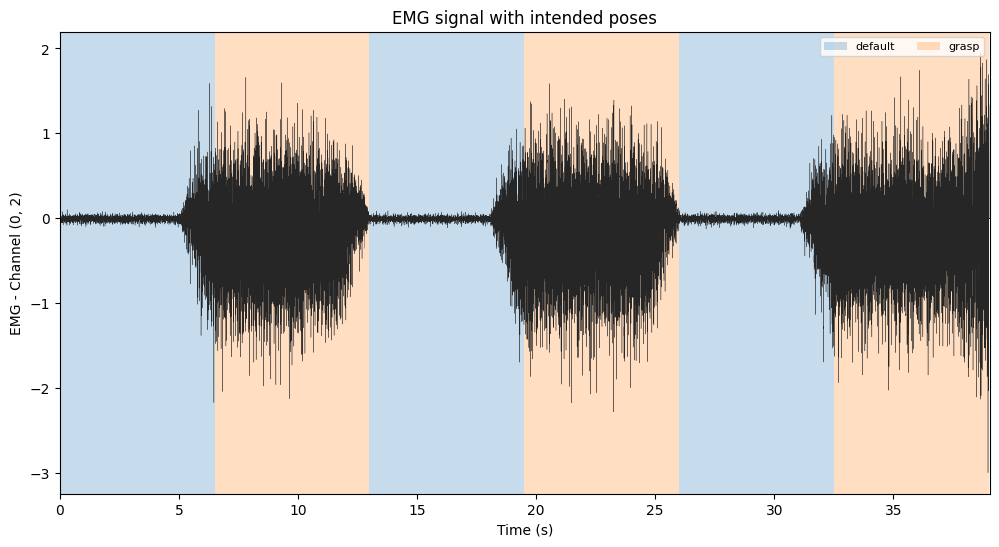

In [7]:
plot_emg_pose(emg_array, poses, durations, fs=fs_curr, channel = (0,2))
plt.show()

In [8]:


def extract_transitions_by_type(emg_signal, durations, poses, fs):
    """
    Extract and concatenate EMG signals by transition type.
    
    Parameters:
    -----------
    emg_signal : np.ndarray
        EMG signal with shape (n_channels, n_samples)
    durations : list
        List of durations in seconds for each pose
    poses : list
        List of pose names (e.g., ['default', 'grasp', ...])
    fs : int
        Sampling frequency in Hz
    
    Returns:
    --------
    dict : Dictionary with transition types as keys and concatenated EMG segments as values
    """
    transition_signals = defaultdict(list)
    
    # Calculate start and end times for each segment
    current_time = 0
    phases = []
    
    for i, (duration, pose) in enumerate(zip(durations, poses)):
        start_time = current_time
        end_time = current_time + duration
        
        # Determine transition type
        if i == len(poses) - 1:
                # Last segment - no next pose
                transition_type = f"{pose}-end"
        else:
            next_pose = poses[i+1]
            if next_pose == pose: ##### When would this occur?? Shouldn't each pose be followed by a different one?? ####
                # And in this case, how would you determine the duration of each pose if it appears to be continuous from the same pose to the next?
                # Same pose as previous = holding
                transition_type = f"{pose}-holding"
            else:
                # Transition from one pose to another
                transition_type = f"{pose}-{next_pose}"
        
        phases.append({
            'start': start_time,
            'end': end_time,
            'duration': duration,
            'pose': pose,
            'type': transition_type,
            'index': i
        })
        
        current_time = end_time
    
    # Extract EMG segments for each phase
    for phase in phases:
        phase_type = phase['type']
        start_idx = int(phase['start'] * fs)
        end_idx = int(phase['end'] * fs)
        
        # Make sure we don't exceed the signal length
        end_idx = min(end_idx, emg_signal.shape[1])
        
        signal_segment = emg_signal[:, start_idx:end_idx]
        transition_signals[phase_type].append(signal_segment)
    
    # Concatenate all segments of the same type
    concatenated_signals = {
        transition_type: np.concatenate(segments, axis=1) 
        for transition_type, segments in transition_signals.items()
    }
    
    return concatenated_signals, phases

In [9]:
# must first flatten to run through extract_transitions_by_type
emg_flat = emg_array.reshape(-1, emg_array.shape[-1])

concatenated_dict, phases = extract_transitions_by_type(emg_flat, durations, poses, fs_curr)

phase_dictionary = {
    'default-holding': concatenated_dict.get('default-holding', None),
    'grasp-holding': concatenated_dict.get('grasp-holding', None),
    'default-grasp': concatenated_dict.get('default-grasp', None),
    'grasp-default': concatenated_dict.get('grasp-default', None)
}


### Decomposition for 'default-holding' phase

In [10]:
defHold_dict = {
    'start_time': 0,
    'end_time': -1,
    'sampling_frequency': fs_curr,
    'low_pass_cutoff': 500,
    'high_pass_cutoff': 20,
    'bad_channels': [],
    'output_source_plot': False,
    'output_final_source_plot': False,
    'verbose_mode': True,
    'extension_factor': 16,
    'whitening_method': "zca",
    'ica_n_inter': 100,
    'opt_initialization': "random",
    'opt_function_exp': 3,
    'opt_max_iter': 100,
    'opt_tol': 1e-4,
    'cluster_method': "kmeans",
    'sil_th': 0.85,
    'cov_th': 0.35,
    'peel_off': True,
    'fr_peeloff': True,
    'phase_to_decompose': "default-holding"
}

defHold_cfg = r"/Users/lizkal/Desktop/NeuroEng/MotorUnitSuite-main/src/configs"

defHold_json = json.dumps(defHold_dict)
with open("defHold_config.json", "w") as f:
    f.write(defHold_json)


In [11]:
emg_phase = concatenated_dict[defHold_dict['phase_to_decompose']]


## 1. Extension

In [12]:

from scipy.linalg import toeplitz

def extension (sig, ext_factor):
    """ Extend signal

    Parameters:
        - sig: ndarray
            Signal with n_channels x n-samples
        - ext_factor: int
            Extension factor defining how many additional samples are added to each channel

    Returns:
        - sig_ext: ndarray
            Extended signal with n_channels * ext_factor x n_samples
    """

    n_channels, n_samples = sig.shape
    sig_ext = np.zeros((n_channels * ext_factor, n_samples))

    for i in range(n_channels):
        col = np.concatenate(([sig[i, 0]], np.zeros(ext_factor-1))) # create new indices for lagged extension, subtract
        # 1 from ext_factor because the first row will be the initial signal in it already
        row = sig[i,:] # keep the rest of the signal data
        lag_channels = toeplitz(col, row) # create lagged array with signal shifted and padded with 0
        sig_ext[i * ext_factor : (i + 1) * ext_factor, :] = lag_channels

    return sig_ext

emg_ext = extension(emg_phase, defHold_dict['extension_factor'])
"""
Should we be taking the zero means of only the unpadded, "real" data?
If we are to remove the padding AFTER we calculate the means, won't this mean that our
unpadded matrix is no longer centered?
"""
emg_ext -= np.mean(emg_ext, axis = 1, keepdims = True) # zero means
""" Why is the padding at extension_factor * 2 removed, and not just extension_factor-1? 
The toeplitz matrix will generate extension_factor - 1 new rows, each with a delay.
Why get rid of extra signal?
"""
emg_ext[:, : defHold_dict['extension_factor'] * 2] = 0 # removing padding at beggining and end of extension array
emg_ext[:, -defHold_dict['extension_factor'] * 2 :] = 0

print(f"Before extension : {emg_phase.shape}")
print(f"After  extension : {emg_ext.shape}   ({emg_phase.shape[0]} channels x {defHold_dict['extension_factor']} lags)")
print(f"Total lag covered: {defHold_dict['extension_factor'] / defHold_dict['sampling_frequency'] * 1000:.1f} ms")

Before extension : (64, 30720)
After  extension : (1024, 30720)   (64 channels x 16 lags)
Total lag covered: 7.8 ms


## Whitening

In [37]:
def whitening (signal, method, factorType, regularization, eps = 1e-10, rank_trunc = None):

    """ Whiten a signal by transforming signal to one with a covariance matrix = I
    Parameters:
    - signal: ndarray
        data to be whitened with n_channels x n_samples, must be centered already
    - method: str ("ZCA", "PCA", or "Cholesky")
        Type of whitening
    - factorType: str ("svd" or "ed")
        Type of factorization technique (single value decomposition or eigen decomposition)
    - regularization: str ("auto") float, or None
    - eps: float
        Small epsilon for numerical stability
    - rank_trunc: float or Non
        Rank-truncated whitening. If a float in (0,1),
        eigen-components with eigenvalue <= rank_trunc * max_eigenvalue are
        DROPPED (their inverse-sqrt set to 0) instead of amplified. This is the
        fix for a near-singular extended-EMG covariance (see mu_xclean/diagnosis):
        the default 'auto' ridge is ~1e-8 and whitens the noise subspace to unit
        variance, drowning the motor units; a truncation of ~1e-3 keeps only the
        components carrying real variance. None (default) preserves the original
        behavior. Applies to both factorTypes and to ZCA/PCA.


    Returns: 
    - signal_white: ndarray
        Whitened array
    - Z: ndarray
        Whitening transformation matrix
    """
    n_channels, n_samples = signal.shape
    covariance = np.cov(signal) #### Modified this from the core.py file

    if method == "Cholesky":
        R = np.linalg.cholesky(covariance) # compute Cholesky decomposition of covariance matrix
        I = np.linalg.inv(R) # compute inverse, whitened matrix

    # use full-matrices=False because we only want the useful infromation returned
    # The function will defaul to full_matrices=True and return a square matrix
    # But, to fill out the square matrix, the function generates random basis extensions which we don't need and are computaitonally expensive
    if factorType == "svd":
        U, S, _ = np.linalg.svd(covariance.astype(np.float64, copy=False), full_matrices=False)

        """
        ``````````````````````````````````````````````````````````````````````````````````````
        What does this regularization below do? -> limits amplification of low variance components
        Also, not clear on how rank_trunc works -> completely removes low variance components
        ``````````````````````````````````````````````````````````````````````````````````````
        """
        # From Negro 2016:
        # The eigenvalue decomposition has been performed with a regularization factor ﬁxed for all recordings to the 
        # average of the smallest half of the eigen-values of the correlation matrix of the extended EMG signals
        # The regularization procedure was applied to reduce the numerical instability of 
        # the solutions of the inverse problem. (ie small changes in signal do not generate large differences
        # in solutions (ex. S1 = 1e-6, S2 = 2e-6. S1^(-1/2) = 1000, S2^(-1/2) = 707 
        # => numerical instability genreated by small changes in input to create large changes in estimated solution
        
        if regularization == "auto":
             # average squares of first/smaller half of eigenvectors (given in descending order from linalg.svd)
            # since these smaller values are assumed to be noise since these values correspond
            # to the directions in data which don't carry much signal/real info (i.e., low variance directions)
            # don't want to rescale by 1/sqrt(S) if these values are very small because this will result in
            # amplifying the noise in those directions which will drown out the real signal with noise in the
            # whitened matrix
            # So we set a regularization term adapted to the current signal which is scaled to the noise
            
            reg = np.mean(S[len(S) // 2 :] ** 2) 
        elif isinstance(regularization, float):
            reg = regularization
        else:
            reg = 0

        S_inv = 1.0 / np.sqrt(S + reg + eps)
        
        if rank_trunc is not None:                       # drop near-null noise subspace
            # keep S-inv where S > rank_trunc * S.max(), 0 everywhere else
            # more strict way than regularization to get rid of noise
            S_inv = np.where(S > rank_trunc * S.max(), S_inv, 0.0) 

        if method == "PCA":
            Z = np.diag(S_inv) @ U.T
        elif method == "ZCA":
            Z = U @ np.diag(S_inv) @ U.T
        else:
            raise ValueError("method not recognized")

        
    else: 
        S, V = np.linalg.eigh(covariance)

        if regularization == "auto":
           
            reg = np.mean(S[: len(S) // 2])
        elif isinstance(regularization, float):
            reg = regularization
        else:
            reg = 0
            
        S_inv = 1.0 / np.sqrt(S + reg + eps)
        if rank_trunc is not None:                       
            S_inv = np.where(S > rank_trunc * S.max(), S_inv, 0.0)

        if method == "ZCA":
            Z = V @ np.diag(S_inv) @ V.T
        elif method == "PCA":
            Z = np.diag(S_inv) @ V.T
        else:
            raise ValueError("method not recognized")
        
    signal_white = Z @ signal
    
    return signal_white, Z

In [38]:
white_sig, Z = whitening(emg_ext, "ZCA", "ed", "auto")

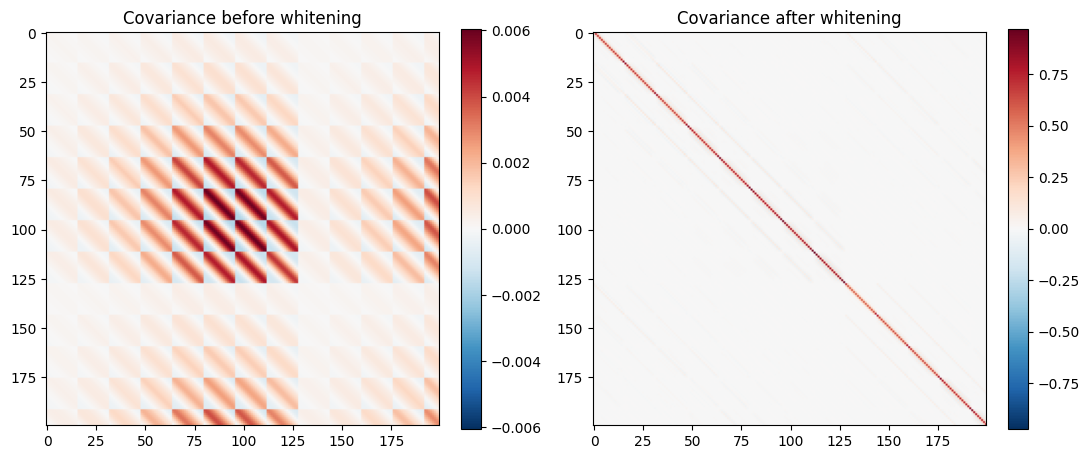

In [39]:
n_show = 200
cov_before = np.cov(emg_ext[:n_show])
cov_after = np.cov(white_sig[:n_show])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, cov, title in zip(axes, [cov_before, cov_after],
                          ['Covariance before whitening', 'Covariance after whitening']):
    im = ax.imshow(cov, cmap='RdBu_r', vmin=-np.abs(cov).max(), vmax=np.abs(cov).max())
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## Source reconstruction

In [40]:
def gram_schmidt(w, B):
    """
    Stabilized Gram-Schmidt orthogonalization.

    Args:
        w (np.ndarray): Input vector to be orthogonalized (shape: [n,])
        B (np.ndarray): Matrix of orthogonal basis vectors in columns (shape: [n, k])

    Returns:
        u (np.ndarray): Orthogonalized vector
    """
    w = np.asarray(w, dtype=float)
    B = np.asarray(B, dtype=float)

    # Remove zero columns from B
    non_zero_cols = ~np.all(B == 0, axis=0)
    B = B[:, non_zero_cols]

    u = w.copy()
    for i in range(B.shape[1]):
        a = B[:, i]
        projection = (np.dot(u, a) / np.dot(a, a)) * a
        u = u - projection

    return u


In [41]:
def fixed_point (sw, sep, B, exp, tol, max_iter, deflation):

    """
    Find optimal separation to increase sparseness of signal by optimizing negentropy
    
    Parameters:
    - sw: ndarray
        signal that has already been whitened
    - sep: ndarray
        initial separation vector with dimensions (n_channels of sw x 1)
    - B: ndarray
        filters with dimensions (n_channels of sw x 1). Used in deflation protocol
    - exp: int
        exponent used in contrast function (to estimate negentropy?)
        Determines how selective the contrast function is:
            higher -> more peaks counted as MUs,
            lower -> MUs which may actually be different get grouped together 
    - tol: int
        Convergence value to determine if system has sufficiently converged. 
    - max_iter: int
        Max number of times the function will loop before ending if optimization has not been completed
    - delfation: str ("gram-schmidt" or "projection_deflation")

    Returns:
    - sep: ndarray
        optimized separation vector
    - k: number of iterations before optimized separation vector determined

    """
    


    eps = 1e-3 # used to keep function diferentiaable @ 0
    g = lambda x: (eps + x**2) ** ((exp - 3) / 2) * (exp * x**2 + eps)
    gp = lambda x: (exp - 1) * x * (eps + x**2) ** ((exp - 5) / 2) * (exp * x**2 + 3 * eps)

    delta = np.ones(max_iter)
    k = 0

    while delta[k] > tol and k < max_iter - 1:
        sep_last = sep.copy() 
        source_est = sep.T @ sw

        # fixed point update formula
        A = np.mean(gp(source_est))
        sep = np.mean(sw * g(source_est), axis = 1) - A*sep


        ## Orthogonalization
        # Deflation to avoid choosing the same strong MU after every loop
        if deflation == "gram-schmidt":
            sep = gram_schmidt(sep, B) # generate new separation vector 
        elif deflation == "projection_deflation":
            sep = sep - (B @ B.T) @ sep # subtract any variance caused by other ICs from the current separation vector to see what remains
        # B@BT is the projection matrix onto the direction of the source in B
        # B @ BT @ sep is the part of sep which points along the filters already found in B
        # sep - (B @ B.T) @ sep subtracts the part of the current filter which lies in the filters already found
        else:
            raise ValueError("deflation method not recognized")

        # Only the direction of w matters, so we keep it on the unit sphere
        # magnitude does not matter so we can just take the norm so that the magnitude of sep = 1
        sep = sep / np.linalg.norm(sep)

        # Convergence: 1 minus the dot product between the new and the old direction (= 0 if current and past vectors converge perfectly)
        delta[k + 1] = abs(np.dot(sep, sep_last) - 1)
        k += 1

    return sep, k
    

Converged in 7 iterations


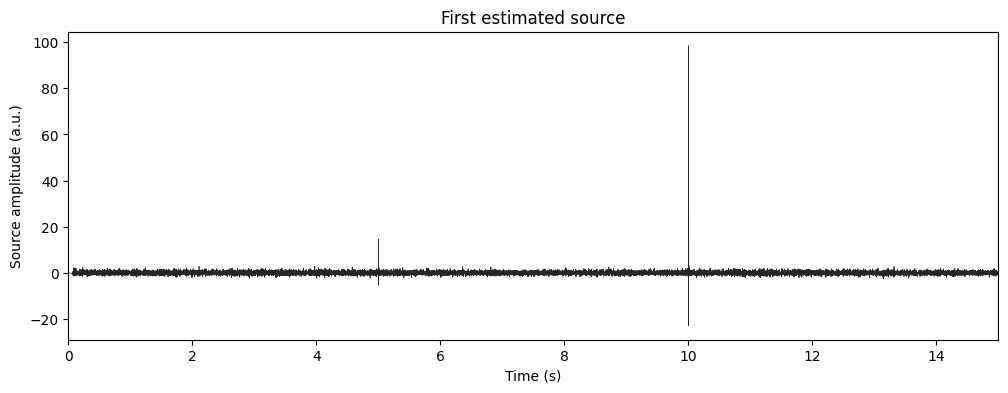

In [42]:
# Reproducibility: the initialization is random, so without a seed you get a different
# source every time you re-run the cell
np.random.seed(1909)

# No filters found yet, so the deflation matrix is empty
mu_filters = np.zeros((white_sig.shape[0], 1))

# 'random' initialization, as set in the configuration section
sep = np.random.randn(white_sig.shape[0])


sep, n_steps = fixed_point(white_sig, sep, mu_filters,
                           # higher exp -> more peaks counted as MUs,
                           # lower exp -> MUs which may actually be different get grouped together 
                           exp=3, 
                           tol=defHold_dict['opt_tol'],
                           max_iter=defHold_dict['opt_max_iter'],
                           deflation="gram-schmidt")

# The source is simply the projection of the whitened data on the filter we just found
source = sep.T @ white_sig ### (S = WTX)

print(f"Converged in {n_steps} iterations")

t = np.arange(source.size) / fs_curr
plt.figure(figsize=(12, 4))
plt.plot(t, source, lw=0.5, color='0.15')
plt.xlabel('Time (s)')
plt.ylabel('Source amplitude (a.u.)')
plt.title('First estimated source')
plt.xlim(0, t[-1])
plt.show()

In [43]:
def est_spike_times(source_sig, exp, fs, min_delay, lower_threshold, upper_threshold, cluster_method):

    """
    Parameters:
        - source_sig: ndarray (n_channels x n_samples)
            signal with estimated source data
        - exp: int
            exponent used in asymmetric power law
        - fs: float
            sampling frequency, Hz
        - min_delay: float
            minimum delay between discharges to be considered as separate in seconds, commonly 0.01
        - lower_threshold: float (0-100)
            value to determine lower threshold to calculate spike outlier before clustering
        - upper_threshold: float (0-100)
            value to determine upper threshold to calculate spike outlier before clustering
       
    Returns:
        - est_spikes: ndarray
            contains estimated spike indices from source signal
        - centroids: ndarray
            centroids for clusters
        - sil: float
            describes distance between spikes and centroids
            High SNR: SIL -> 1 (A source where spikes and noise form two obviously distinct clouds)
            Low SNR: SIL -> 0 (a source where the peak heights are one continuous smear)
    """

    # Asymmetric power law that can be useful for contrast enhancement
    source_sig = np.sign(source_sig) * np.abs(source_sig)**exp

    # find local max:
    min_dis_dist = fs * min_delay    
    # find_peaks to find indices of local max taking threshold distance into account
    peaks, _ = find_peaks(source_sig, distance=min_dis_dist)

    if len(peaks) == 0:
        return np.array([]), np.array([]), 0.0
        
    peak_vals = source_sig[peaks].reshape(-1, 1) # 1 column, n rows to fit the rest (-1)
    
    
    """ When is kmeans used over kmedoids? Larger datasets when computational efficiency makes a difference?
    Also, why filter outliers before both methods if kmedoids is more robust and less sensitive to outliers?
    How do we choose the threshold for outliers as 99.9? ex rather than 3 sd > mean?
    Only have upper outlier threshold because this is signal and the lower threshold would be noise anyways .?
    """
    
    # Must first remove outliers (kmeans is sensitive to outliers)
    threshold_vals = np.percentile(peak_vals, [lower_threshold, upper_threshold])
    remove_outliers = (peak_vals.flatten() >= threshold_vals[0]) & (peak_vals.flatten() <= threshold_vals[1])
    peaks = peaks.reshape(-1,1) # reshape to remove outliers in correct dimension

    if remove_outliers is not None:
        peak_vals_clean = peak_vals[remove_outliers]
        peaks_clean = peaks[remove_outliers]

    else:
        peak_vals_clean = peak_vals
        peaks_clean = peaks

    if len(peak_vals_clean) == 0:
        return np.array([]), np.array([]), 0.0

    if cluster_method == "kmeans":
        model = KMeans(n_clusters = 2, n_init = 10, random_state = 42) # where does the n_inter value come from here?
    elif cluster_method == "kmedoids":
        model = KMedoids(n_clusters = 2, random_state = 42)
    else:
        raise ValueError('cluster method type not recognized')
    labels = model.fit_predict(peak_vals_clean) #gives labels (0 or 1) to data according to model and which cluster it belongs to
    centroids = model.cluster_centers_.flatten()

    spike_cluster = np.argmax(centroids) # index of largest centroid (=1)
    est_spikes = peaks_clean[labels == spike_cluster]
    
    # determine how far each point is from its own and the other cluster
    D = model.transform(peak_vals_clean)
    # determine the sum of distances for points within a cluster
    # labels == spike_cluster to filter D based off of spike cluster
    # spike_cluster, spike_cluster to select spike distances to its own centroid
    d_within = np.sum(D[labels == spike_cluster, spike_cluster]) ** 2
    d_between = np.sum(D[labels == spike_cluster, 1-spike_cluster]) ** 2
    denom = max(d_within, d_between)
    sil = (d_between - d_within)/denom if denom > 0  else 0.0

    return est_spikes, centroids, sil


In [20]:
def isi_cov(spike_train, fs):

    """
    Parameters:
        - spike_train: ndarray
            spike train of spike indices
        - fs: float
            sampling frequency

    Returns:
        - isi_cov: float
            coefficient of variation for the inter-spike intervals

    """

    # sum all the isis
    # take the covariance
    spike_train = np.asarray(spike_train, dtype=int)
    if spike_train.size <= 2:
        return np.inf
    isi = np.diff(spike_train/fs, axis = 0)

    return np.std(isi) / np.mean(isi) if np.mean(isi) > 0 else np.inf


In [21]:
est_spikes, centroids, sil = est_spike_times(source, 2, fs_curr, 0.01, 2, 98, cluster_method = "kmeans")

In [45]:
spike_cov = isi_cov(est_spikes, fs_curr)
fr = len(est_spikes) / (source.size / fs_curr)
print(defHold_dict['sil_th'])

print(f"Spikes detected : {len(est_spikes)}")
print(f"Silhouette (SIL): {sil.item():.3f}   (threshold: {defHold_dict['sil_th']})")
print(f"CoV of the ISI  : {spike_cov.item():.3f}   (threshold: {defHold_dict['cov_th']})") 
"""
if CoV > 1, should the outlier threshold be more conservative?
yes, increasing thresholds from 0.1, 99.9 to 2, 98 decreases threshold from 1.080 to 0.905, and sil from 0.848 to 0.872
fs from 6.60 Hz to 10.67 Hz
No change in K-means centroids (noise, spike): from [ 2.77508065 28.19992605]
- Why not?
"""
print(f"Firing rate     : {fr:.2f} Hz")
print(f"K-means centroids (noise, spike): {np.sort(centroids)}")

0.85
Spikes detected : 310
Silhouette (SIL): 0.900   (threshold: 0.85)
CoV of the ISI  : 0.818   (threshold: 0.35)
Firing rate     : 20.67 Hz
K-means centroids (noise, spike): [0.78666534 2.44266061]


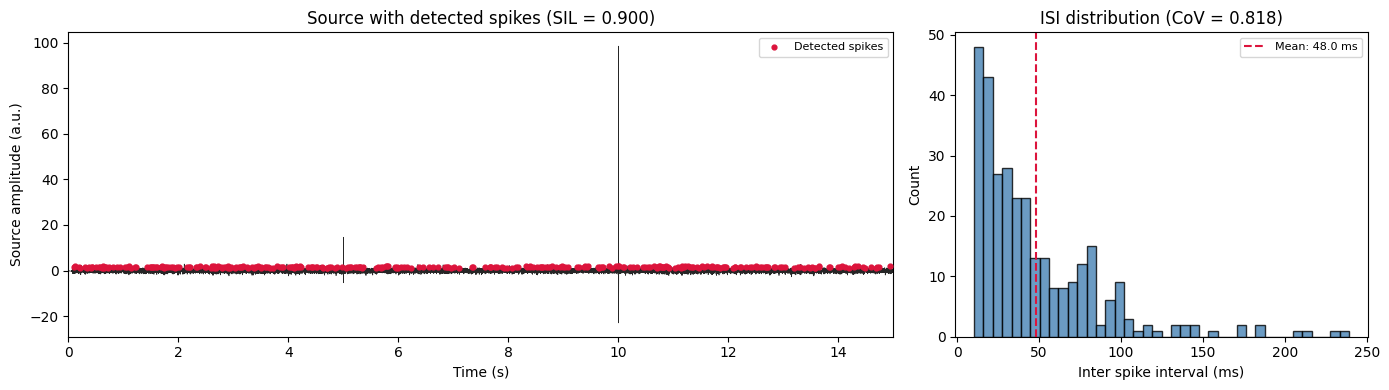

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [2, 1]})

axes[0].plot(t, source, lw=0.5, color='0.15')
if len(est_spikes) > 0:
    axes[0].scatter(est_spikes / fs_curr, source[est_spikes], color='crimson', s=12, zorder=5, label='Detected spikes')
    axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Source amplitude (a.u.)')
axes[0].set_title(f'Source with detected spikes (SIL = {sil:.3f})')
axes[0].set_xlim(0, t[-1])

if len(est_spikes) > 2:
    isi = np.diff(est_spikes, axis = 0) / fs_curr * 1000  # in milliseconds, easier to read
    axes[1].hist(isi, bins=40, color='steelblue', edgecolor='black', alpha=0.8)
    axes[1].axvline(np.mean(isi), color='crimson', ls='--', label=f'Mean: {np.mean(isi):.1f} ms')
    axes[1].legend(fontsize=8)
axes[1].set_xlabel('Inter spike interval (ms)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'ISI distribution (CoV = {spike_cov:.3f})')

plt.tight_layout()
plt.show()

## Refinement
Derived from CKC since fixed-point algorithm may converge to unreliable estimates
improves estimate of separation vector until reaching minimum variability of discharge

In [24]:
# take the source that we just found from the fixed-point iteration algorthim and iterate it again with the whitened signal
# use this signal to find spikes again, and keep iterating through so long as CoV decrease

In [25]:
def refine_cov_isi(w, signal, fs, cov):

    """
    Parameters:
        - w: nd_array
            The current estimate derived from the fixed_point algorithm
        - signal: nd_array
            The original whitened signal to be refined
        - fs: float
            Sampling frequency
        - cov: float
            Coefficient of variance for spike estimate

    Returns:
        - source_est: nd_array
            source signal
        - spike_ref: nd_array
            The refined spike train
        - centroid_ref: nd_array
            Refined centroids
        - sil_ref: float (0-1)
            The silhouette measure of refined signal
        - cov_ref: float
            The coefficient of variance for the isi of refined signal
    """

    cov_last = cov + 1 # itialize so the first loop always runs

    while cov_last > cov:
        source_est = w.T @ signal
        spike_ref, centroid_ref, sil_ref = est_spike_times(source_est, 2, fs, 0.01, 2, 98, "kmeans")
        cov_last = cov
        # cov = isi_cov(spike_ref, fs)
        isi = np.diff(spike_ref / fs)
        cov = np.std(isi) / np.mean(isi)

        # new filter is the signal at the new refined spikes
        w = np.mean(signal[:, spike_ref], axis=1)
        w = w / np.linalg.norm(w)

    return w, spike_ref, centroid_ref, sil_ref, cov

# def minimize_cov_isi(w, X, cov, fsamp, cluster='kmeans'):
# """
#     Parameters:
#     - w: np.ndarray, the filter coming out of the fixed point algorithm
#     - X: np.ndarray, the whitened signal
#     """

#     while cov < cov_last:
#         # Current estimate of the source and of its discharges
#         source = w.T @ X
#         spikes, _, _ = est_spike_times(source, fsamp, cluster=cluster)

#         cov_last = cov
#         isi = np.diff(spikes / fsamp)
#         cov = np.std(isi) / np.mean(isi)

#         # The new filter is the average of the whitened signal at the discharge instants
#         w = np.mean(X[:, spikes], axis=1)
#         w = w / np.linalg.norm(w)

#     return w, spikes, cov

    # return w, spikes, cov

## Generate Wavefore + Peel off

In [27]:
def spike_avg(signal, spikes, fs, window):
    """
    Parameters
        signal: ndarray (2D)
            - Signal of interest with dimensions n_channels x n_samples
        spikes: ndarray (1D)
            - indices of spikes from signal
        fs: float
            - sampling frequency (Hz)
        window: float
            - size for MUAP template (s)

    Returns
        waveform: ndarray (2D)
            - estimated response template for a single source
    """

    width = int(window * fs)
    waveform = np.zeros((signal.shape[0], 2*width + 1)) # center around middle of spike
    # so we have a waveform which spans 2x the width and accounts for the spike itself at the center

    """
    changed code below, why do we need to +/- 1 from the widths? To be extra conservative?
    Also, is there any real limitation to getting rid of signals which fall close to the boundaries, 
    below we are getting rid of those which don't have enough width buffering on either end
    Could you convolve with a wavelet or something to add a taper???
    """
    spikes = spikes[(spikes >= width) & (spikes <= signal.shape[1] - width)]

    for i in np.arange(len(spikes)):
        waveform = waveform + signal[:, (spikes[i]-width) : (spikes[i]+width+1)]

    waveform /= len(spikes)

    return waveform
    

    


In [28]:
def peel_off(signal, spikes, fs, window):
    """
    Parameters:
        signal: ndarray (2D)
            - signal of interest with source to be peeled off from (n_channels x n_timepoints)
        spikes: ndarray (1D)
            - indices of spikes from signal
        fs: float
            - sampling frequency (Hz)
        window: float
            - period of time to consider a waveform (1/2 waveform width, s)

    Returns:
        signal_peeled: ndarray (2D)
            - signal with source waveform removed (n_channels x n_timepoints)
        comp_sig: ndarray (2D)
            - contribution of source to signal
        waveform: ndarray (2D)
            - estimated response template for a single source

    """
    waveform = spike_avg(signal, spikes, fs, window)
    width = window * fs
    spikes = spikes[(spikes >= width) & (spikes <= signal.shape[1] - width)]

    firings = np.zeros(signal.shape[1])
    firings[spikes] = 1

    # Create padding to increase columns in waveform to match signal
    L = signal.shape[1]
    pad_len = L - waveform.shape[1]
    waveform_padded = np.pad(waveform, ((0,0), (0, pad_len)), mode = "constant")

    # frequency domain of firings for all channels 
    fft_firings = fft(firings)
    # frequency domain for waveforms at each channel
    fft_waveform = fft(waveform_padded, axis = 1)
    # fft product to broadcast firings to each channel
    fft_prod = fft_waveform * fft_firings

    # convert back to time domain
    comp_sig = np.real(ifft(fft_prod, axis = 1))

    # must shift signal due to FFT convolution to get center of signal
    shift = (waveform.shape[1] -1)// 2
    comp_sig = np.roll(comp_sig, -shift, axis = 1)

    signal_peeled = sig-comp_sig
        

    return signal_peeled, comp_sig, waveform

In [ ]:
test_waveform = spike_avg(white_sig, spike_ref, fs_curr, 0.02)
width = int(0.02 * fs_curr)
test_spikes = spike_ref[(spike_ref >= width) & (spike_ref <= white_sig.shape[1] - width)]

firings2 = np.zeros(white_sig.shape[1])


""" adding this section in to shift the firings to the middle of the waveform before convolution instead of after """
# set to 1 on time axis when source fired, 0 at all other time points
# firings[test_spikes] = 1
firings2[test_spikes - width] = 1
# now the firing = 1 at the beginning of each waveform. When we complete the fft convolution,
# the beginning of the waveform will be aligned with the firings

# Create padding to increase columns in waveform to match white_sig
L = white_sig.shape[1]
pad_len = L - waveform.shape[1]
waveform_padded = np.pad(test_waveform, ((0,0), (0, pad_len)), mode = "constant")

# frequency domain of firings for all channels 
# can do this across all channels because firing time points is the same irrespective of the channel
fft_firings2 = fft(firings2)
# frequency domain for waveforms at each channel
# must do at each channel beacuse the waveform seen at each channel is different
fft_waveform = fft(waveform_padded, axis = 1)
# fft product to broadcast firings to each channel
fft_prod2 = fft_waveform * fft_firings2

# convert back to time domain
test_comp_sig2 = np.real(ifft(fft_prod2, axis = 1))

""" Don't need to do this anymore because we accounted for this shift before the fft """
# # must shift white_sig due to FFT convolution to get center of white_sig
# shift = (waveform.shape[1] -1)// 2
# test_comp_sig = np.roll(test_comp_sig, -shift, axis = 1)

test_sig_peeled2 = white_sig-test_comp_sig2

**why use 40ms window when we previously separated spikes by 10ms since discharge rates could not be faster than this. Why not use 20ms window with 10ms on each end in this case? Is it that an entire MUAP is around 40ms, but can cell can refire after 10ms even if entire MUAP is completed?**


In [ ]:
firings = np.zeros(white_sig.shape[1])


# set to 1 on time axis when source fired, 0 at all other time points
firings[test_spikes] = 1


# Create padding to increase columns in waveform to match white_sig
L = white_sig.shape[1]
pad_len = L - waveform.shape[1]
waveform_padded = np.pad(test_waveform, ((0,0), (0, pad_len)), mode = "constant")

# frequency domain of firings for all channels 
# can do this across all channels because firing time points is the same irrespective of the channel
fft_firings = fft(firings)
# frequency domain for waveforms at each channel
# must do at each channel beacuse the waveform seen at each channel is different
fft_waveform = fft(waveform_padded, axis = 1)
# fft product to broadcast firings to each channel
fft_prod = fft_waveform * fft_firings

# convert back to time domain
test_comp_sig = np.real(ifft(fft_prod, axis = 1))

# must shift white_sig due to FFT convolution to get center of white_sig
shift = (test_waveform.shape[1] -1)// 2
test_comp_sig = np.roll(test_comp_sig, -shift, axis = 1)

test_sig_peeled = white_sig-test_comp_sig

In [ ]:
""" testing if two methods of centering waveform produce same peeled array"""
print(np.allclose(
    test_sig_peeled,
    test_sig_peeled2,
    rtol=1e-10,
    atol=1e-12
))

diff = np.abs(test_sig_peeled - test_sig_peeled2)

idx = np.unravel_index(np.argmax(diff), diff.shape)

print("largest difference:", diff[idx])
print("location:", idx)
print("peeled 1:", test_sig_peeled[idx])
print("peeled 2:", test_sig_peeled2[idx])
## -> yes the do :)
